**The brief.** You are the (only) data scientist at a small movie-streaming startup. The
product team wants a "Recommended for you" row, and your manager asks a sharp question:
*which recommender should we ship, and how do you know it is good?* In this capstone you
build two recommenders (the ones from L22), evaluate them **two ways** -- a rating-error
metric (L23) and a **ranking** metric you compute here for the first time -- and write the
one paragraph your manager actually wants. The twist you are about to discover: the "best"
model depends entirely on which metric you trust. Builds on
[L22 (collaborative filtering & matrix factorization)](l22_concept_collaborative_filtering.qmd)
and [L23 (other recommender families + how to evaluate)](l23_concept_content_based_recommenders.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u06_recommender_systems/l24_lab_recommender_mini_project.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l24_lab_recommender_mini_project.ipynb`) -- in Colab via the badge above, or
> locally. Needs network access the first time (it downloads MovieLens 100k).
> Every text output below comes from actually running the cells. This is a capstone:
> less step-by-step hand-holding, more judgment.

## Prerequisites & Setup

The same **MovieLens 100k** as L22/L23 (GroupLens; runtime-download, not redistributed).
We reuse the collaborative-filtering and matrix-factorization code you already understand --
the point of the capstone is the *evaluation* and the *decision*, not new model code.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + download + load. Safe to re-run.
import os, hashlib, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
MD5 = "0e33842e24a9c977be4e0107933c0723"
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/ml-100k/u.data"):
    urllib.request.urlretrieve(URL, "data/ml-100k.zip")
    assert hashlib.md5(open("data/ml-100k.zip", "rb").read()).hexdigest() == MD5, "checksum mismatch"
    with zipfile.ZipFile("data/ml-100k.zip") as z:
        z.extractall("data")

ratings = pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user", "item", "rating", "ts"])
GENRES = ["unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
          "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
          "Romance", "Sci-Fi", "Thriller", "War", "Western"]
items = pd.read_csv("data/ml-100k/u.item", sep="|", encoding="latin-1",
                    names=["item", "title", "release", "video", "imdb"] + GENRES)
title = items.set_index("item")["title"]
print("MovieLens 100k loaded:", ratings.shape[0], "ratings")

MovieLens 100k loaded: 100000 ratings


<details><summary>Expected Output</summary>

~~~text
MovieLens 100k loaded: 100000 ratings
~~~
</details>

## Step 1: Signals and the Evaluation Plan

These are **explicit** ratings (1-5 stars the user chose to give). To judge a recommender
honestly we **hold out** part of the data, build on the rest, and check the predictions
against what we hid. For the ranking check, a movie counts as **relevant** to a user if they
rated it **>= 4** in the held-out set -- a movie they actually liked.

In [3]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"explicit ratings: {len(ratings)} | train: {len(train)} | test: {len(test)}")
print("relevant = held-out items rated >= 4 (a 'liked' movie)")

explicit ratings: 100000 | train: 80000 | test: 20000
relevant = held-out items rated >= 4 (a 'liked' movie)


<details><summary>Expected Output</summary>

~~~text
explicit ratings: 100000 | train: 80000 | test: 20000
relevant = held-out items rated >= 4 (a 'liked' movie)
~~~
</details>

## Step 2: Build Three Recommenders (Worked -- reuses L22)

Three candidates: a **popularity** baseline (recommend the most-rated movies to everyone --
no personalization), **item-item collaborative filtering**, and **matrix factorization**. The
CF and MF code is exactly L22's, trained here on the training split.

In [4]:
gm = train.rating.mean()

# 1) popularity: rank by how many ratings each movie has (most-watched)
cnt = train.groupby("item").size()
pop_score = np.array([cnt.get(i, 0) for i in range(1, 1683)], float)
print("popularity baseline -- the 5 most-rated movies (same for everyone):")
for i in np.argsort(-pop_score)[:5] + 1:
    print(f"{int(cnt.get(i, 0)):4d} ratings  {title.loc[i]}")

popularity baseline -- the 5 most-rated movies (same for everyone):
 451 ratings  Star Wars (1977)
 408 ratings  Fargo (1996)
 406 ratings  Return of the Jedi (1983)
 397 ratings  Contact (1997)
 390 ratings  Scream (1996)


<details><summary>Expected Output</summary>

~~~text
popularity baseline -- the 5 most-rated movies (same for everyone):
 451 ratings  Star Wars (1977)
 408 ratings  Fargo (1996)
 406 ratings  Return of the Jedi (1983)
 397 ratings  Contact (1997)
 390 ratings  Scream (1996)
~~~
</details>

In [5]:
# 2) item-item collaborative filtering (L22) on the training split
Rtr = (train.pivot(index="user", columns="item", values="rating")
       .reindex(index=range(1, 944), columns=range(1, 1683)).values)
rated_tr = ~np.isnan(Rtr)
umean = np.where(rated_tr.any(1), np.nan_to_num(np.nanmean(np.where(rated_tr, Rtr, np.nan), axis=1)), gm)
Rc = np.where(rated_tr, Rtr - umean[:, None], 0.0)
inorm = np.sqrt((Rc**2).sum(0)); inorm[inorm == 0] = 1e-9
S = (Rc.T @ Rc) / np.outer(inorm, inorm); np.fill_diagonal(S, 0.0)
num = Rc @ S; den = rated_tr.astype(float) @ np.abs(S)
pred_cf = umean[:, None] + np.divide(num, den, out=np.zeros_like(num), where=den > 0)

# 3) matrix factorization (L22) on the training split
uix = {u: k for k, u in enumerate(sorted(ratings.user.unique()))}
iix = {i: k for k, i in enumerate(sorted(ratings.item.unique()))}
tr = np.array([[uix[u], iix[i], r] for u, i, r in train[["user", "item", "rating"]].values])
rng = np.random.default_rng(42)
K, lr, reg, epochs = 20, 0.01, 0.05, 20
P = rng.normal(0, 0.1, (len(uix), K)); Q = rng.normal(0, 0.1, (len(iix), K))
bu = np.zeros(len(uix)); bi = np.zeros(len(iix))
for _ in range(epochs):
    rng.shuffle(tr)
    for u, i, r in tr:
        u, i = int(u), int(i)
        e = r - (gm + bu[u] + bi[i] + P[u] @ Q[i])
        bu[u] += lr * (e - reg * bu[u]); bi[i] += lr * (e - reg * bi[i])
        Pu = P[u].copy()
        P[u] += lr * (e * Q[i] - reg * P[u]); Q[i] += lr * (e * Pu - reg * Q[i])
pred_mf = np.full((943, 1682), -9.0)
for u1 in range(1, 944):
    pred_mf[u1 - 1] = gm + bu[uix[u1]] + bi + P[uix[u1]] @ Q.T
print("built: popularity, item-item CF, matrix factorization")

built: popularity, item-item CF, matrix factorization


<details><summary>Expected Output</summary>

~~~text
built: popularity, item-item CF, matrix factorization
~~~
</details>

## Step 3: Evaluate Two Ways

**(a) Rating prediction -- RMSE (from L23).** How close are the predicted stars to the truth?
A popularity *ranker* does not predict a star rating, so we score only the two real predictors.

In [6]:
def rmse(pred):
    p = np.clip(np.array([pred[u - 1, i - 1] for u, i in zip(test.user, test.item)]), 1, 5)
    return np.sqrt(((p - test.rating.values)**2).mean())

print(f"item-item CF RMSE:         {rmse(pred_cf):.3f}")
print(f"matrix factorization RMSE: {rmse(pred_mf):.3f}")

item-item CF RMSE:         0.945
matrix factorization RMSE: 0.922


<details><summary>Expected Output</summary>

~~~text
item-item CF RMSE:         0.945
matrix factorization RMSE: 0.922
~~~
</details>

**(b) Ranking -- precision@k (NEW).** Users never see a predicted star; they see a *ranked
list*. **precision@k** asks: of the top `k` movies we put in front of a user, how many were
actually relevant (a held-out movie they rated >= 4)? We average it over all users. This is
the metric L23 named but did not compute -- here it is.

In [7]:
test_rel = test[test.rating >= 4].groupby("user").item.apply(set)   # liked, held-out
train_items = train.groupby("user").item.apply(set)                 # already seen

def precision_at_k(pred, k=10):
    ps = []
    for u in test_rel.index:
        rel = test_rel[u]
        if not rel:
            continue
        sc = pred[u - 1].copy()
        for i in train_items.get(u, set()):
            sc[i - 1] = -np.inf                     # do not recommend already-seen movies
        topk = np.argsort(-sc)[:k] + 1              # the k highest-scored unseen movies
        ps.append(sum(1 for i in topk if i in rel) / k)
    return np.mean(ps)

pop_mat = np.tile(pop_score, (943, 1))             # popularity: same ranking for every user
p_pop, p_cf, p_mf = precision_at_k(pop_mat), precision_at_k(pred_cf), precision_at_k(pred_mf)
print(f"popularity precision@10:   {p_pop:.3f}")
print(f"item-item CF precision@10: {p_cf:.3f}")
print(f"matrix factorization p@10: {p_mf:.3f}")

popularity precision@10:   0.136
item-item CF precision@10: 0.032
matrix factorization p@10: 0.070


<details><summary>Expected Output</summary>

~~~text
popularity precision@10:   0.136
item-item CF precision@10: 0.032
matrix factorization p@10: 0.070
~~~
</details>

## Step 4: Reconcile and Decide

Put the two metrics side by side.

In [8]:
board = pd.DataFrame({
    "RMSE (lower=better)": ["n/a (ranker)", f"{rmse(pred_cf):.3f}", f"{rmse(pred_mf):.3f}"],
    "precision@10 (higher=better)": [f"{p_pop:.3f}", f"{p_cf:.3f}", f"{p_mf:.3f}"],
}, index=["popularity", "item-item CF", "matrix factorization"])
print(board.to_string())

                     RMSE (lower=better) precision@10 (higher=better)
popularity                  n/a (ranker)                        0.136
item-item CF                       0.945                        0.032
matrix factorization               0.922                        0.070


<details><summary>Expected Output</summary>

~~~text
                     RMSE (lower=better) precision@10 (higher=better)
popularity                  n/a (ranker)                        0.136
item-item CF                       0.945                        0.032
matrix factorization               0.922                        0.070
~~~
</details>

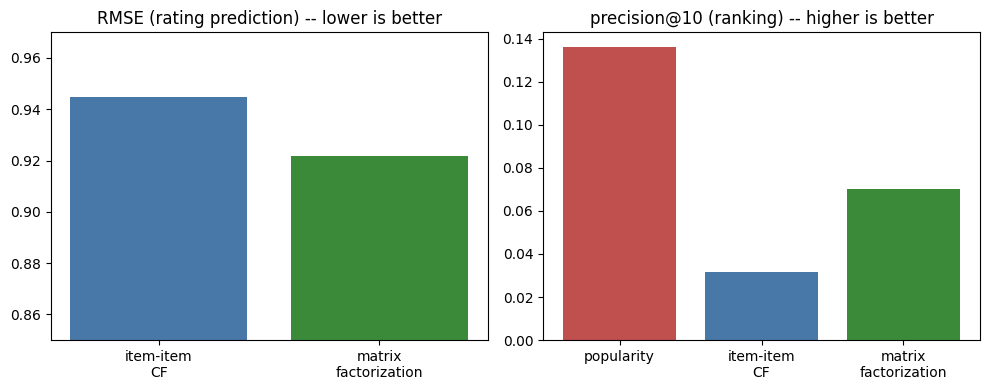

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(["item-item\nCF", "matrix\nfactorization"], [rmse(pred_cf), rmse(pred_mf)],
          color=["#4878a8", "#3a8a3a"])
ax[0].set_ylim(0.85, 0.97); ax[0].set_title("RMSE (rating prediction) -- lower is better")
ax[1].bar(["popularity", "item-item\nCF", "matrix\nfactorization"], [p_pop, p_cf, p_mf],
          color=["#c0504d", "#4878a8", "#3a8a3a"])
ax[1].set_title("precision@10 (ranking) -- higher is better")
plt.tight_layout(); plt.show()

> **Reading the figure:** the two panels crown different winners. On the left,
> matrix factorization's RMSE bar is the lower (better) one. On the right, the
> popularity bar towers over both personalized models -- the opposite verdict.

**The twist.** The two leaderboards **disagree**. By RMSE, matrix factorization is the best
recommender (0.922, beating CF's 0.945). By precision@10, the *dumbest* approach -- recommend
the most-popular movies to everyone -- wins easily (**0.136**, nearly double matrix
factorization's 0.070, and four times CF's 0.032).

Both results are real, and together they are the whole lesson:

- **RMSE rewards predicting individual ratings well; precision@k rewards ordering the list
  well.** A model can nail the first and still lose the second -- exactly L23's warning, now
  measured. The matrix-factorization model that predicts your stars most accurately is *not*
  the one that gets the most movies-you-will-like into the top 10.
- **Popularity is a brutally strong ranking baseline.** Most people like the famous movies, so
  recommending Star Wars and Fargo to everyone scores well on precision@k. Any personalized
  recommender has to *beat popularity* to earn its place -- and here, on raw precision@10,
  neither does.
- **So which do you ship?** Not pure popularity: it gives everyone the identical list, adds no
  personalization, and feeds the filter bubble (L23). You ship a **personalized** model
  (matrix factorization is the stronger of the two here) **measured on the metric that matches
  the product** -- a ranking metric, not RMSE -- and you keep popularity as the baseline to
  beat and as the **cold-start** default for brand-new users (then personalize as ratings
  arrive, the L23 plan). The honest report gives your manager *both* numbers and names the
  trade-off, instead of crowning one model from one metric.

## Your Turn (Exercises)

### Exercise 1 -- precision@5

In [10]:
# TODO: compute precision@5 (call precision_at_k with k=5) for popularity, CF, and MF.
# Does the popularity-wins-the-ranking story still hold at k=5?

### Exercise 2 -- add a third recommender

In [11]:
# TODO: add a content-based recommender (the genre-cosine method from L23) or a hybrid,
# build its score matrix, and add a row to the two-metric leaderboard. Where does it land?

### Exercise 3 -- the decision (written, 4-6 sentences)
Write the paragraph your manager asked for: **which recommender would you ship and why**,
**which metric you would optimize and why it matches the product**, and **your plan for
brand-new users** (the cold-start problem from L22/L23). Use the numbers from your table.

## Summary

- You ran the full recommender loop end to end: **build** (popularity, CF, MF) -> **evaluate**
  (RMSE *and* precision@10) -> **decide**.
- **precision@k** measures ranking quality (how many of the top-k are relevant) -- different
  from RMSE's rating-prediction error.
- The leaderboards **disagreed**: MF won RMSE (0.922), popularity won precision@10 (0.136). The
  "best" model depends on the metric -- so choose the metric that matches what users experience.
- **Popularity is the baseline to beat**, and the cold-start default; you ship a personalized
  model judged on a ranking metric, and report both numbers honestly.
- Unit VI is complete. Next, **Unit VII** swaps the ratings table for a *graph*: social
  networks, neighborhoods, and communities.